#  Car Price Prediction Using Linear Regression

This project aims to predict the price of used cars using **Linear Regression**. The dataset contains information about cars such as model, manufacturing year, mileage, transmission, fuel type, tax, MPG, engine size, and manufacturer.

The project follows a complete machine learning workflow including **data loading, data inspection, data cleaning, exploratory data analysis (EDA), feature selection, model training, model evaluation, model improvement, preprocessing, pipeline creation, validation, testing, and model saving using Pickle**.

#  Data Loading and Initial Inspection

The first stage of the project focuses on loading the car dataset and understanding its basic structure.

The dataset is loaded into a Pandas DataFrame, after which the first few records, statistical summary, dataset dimensions, data types, and unique values are examined. This initial inspection helps understand the available features and identify potential data quality issues before performing further analysis.

### Importing Required Libraries

The following Python libraries are imported for **data analysis, numerical operations, data visualization, and statistical visualization**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Loading the Dataset

The following code is used to load the **cars dataset** from a CSV file into a Pandas DataFrame.

In [2]:
df= pd.read_csv("cars_dataset.csv")

### Viewing the First Few Rows

The `head()` function is used to display the **first 5 rows** of the DataFrame.


In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi


### Statistical Summary of the Dataset

The `describe()` function is used to generate a **statistical summary of the numerical columns** in the DataFrame.


In [4]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16580.158708,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.028754,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


### Checking the Shape of the Dataset

The `shape` attribute is used to find the **number of rows and columns** present in the DataFrame.


In [5]:
df.shape

(72435, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  str    
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  str    
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  str    
 6   tax           72435 non-null  float64
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  str    
dtypes: float64(3), int64(3), str(4)
memory usage: 5.5 MB


### Checking Unique Values in Each Column

The following loop is used to display the **unique values present in every column** of the DataFrame.


In [7]:
for col in df.columns:
    print(col ," '", df[col].unique())
    # print(df[col].value_counts())

model  ' <StringArray>
[      ' A1',       ' A6',       ' A4',       ' A3',       ' Q3',       ' Q5',
       ' A5',       ' S4',       ' Q2',       ' A7',
 ...
    ' Ioniq',     ' Kona', ' Veloster',     ' I800',     ' IX20', ' Santa Fe',
   ' Accent', ' Terracan',     ' Getz',    ' Amica']
Length: 146, dtype: str
year  ' [2017 2016 2019 2015 2014 2018 2013 2020 2004 2009 2012 2010 2007 2011
 2008 2003 2005 2002 2006 1998 1997 2001 2000 1999 1996]
price  ' [12500 16500 11000 ... 16445 21839  3095]
transmission  ' <StringArray>
['Manual', 'Automatic', 'Semi-Auto', 'Other']
Length: 4, dtype: str
mileage  ' [15735 36203 29946 ... 13810 23313 11472]
fuelType  ' <StringArray>
['Petrol', 'Diesel', 'Hybrid', 'Other', 'Electric']
Length: 5, dtype: str
tax  ' [150.  20.  30. 145. 125. 200.   0. 205. 160. 235. 260. 325. 300. 165.
 240. 565. 265. 135. 570. 555. 140. 330. 305. 155. 580. 290. 195. 115.
 295. 220. 230. 280. 315. 535. 190. 540. 515. 110. 185. 120. 250. 245.
 255. 270. 130. 210.  10.]

#  Data Cleaning and Preprocessing

Before building the model, the dataset is checked for common data quality problems such as missing values and duplicate records.

Missing values are identified using `isnull()`, while duplicate records are detected using `duplicated()`. The duplicate records found in the dataset are removed, and the dataset is checked again to confirm that the cleaning process was successful.

This step ensures that duplicate observations do not unnecessarily influence the model during training.

### Checking for Missing Values

The following code is used to check the number of **missing (null) values** in each column of the DataFrame.


In [8]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

### Checking for Duplicate Records

The following code is used to identify **duplicate rows** in the dataset.


In [9]:
df.duplicated().sum()
df[df.duplicated()]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
273,Q3,2019,34485,Automatic,10,Diesel,145.0,47.1,2.0,audi
764,Q2,2019,22495,Manual,1000,Diesel,145.0,49.6,1.6,audi
784,Q3,2015,13995,Manual,35446,Diesel,145.0,54.3,2.0,audi
967,Q5,2019,31998,Semi-Auto,100,Petrol,145.0,33.2,2.0,audi
990,Q2,2019,22495,Manual,1000,Diesel,145.0,49.6,1.6,audi
...,...,...,...,...,...,...,...,...,...,...
71802,Santa Fe,2019,32995,Semi-Auto,30,Diesel,145.0,40.9,2.2,Hyundai
71952,Tucson,2016,10991,Manual,108000,Diesel,125.0,58.9,2.0,Hyundai
71954,I30,2015,4492,Manual,124000,Diesel,0.0,78.4,1.6,Hyundai
72416,I40,2017,11485,Manual,17393,Diesel,145.0,65.7,1.7,Hyundai


### Removing Duplicate Records

The `drop_duplicates()` function removes duplicate rows from the dataset and keeps only unique records.


In [10]:
df=df.drop_duplicates()

### Checking for Duplicate Records

This code checks the number of duplicate rows remaining in the dataset after removing duplicates.

In [11]:
df.duplicated().sum()

np.int64(0)

### Checking Dataset Shape

This code displays the **number of rows and columns** in the dataset.

In [12]:
df.shape

(71593, 10)

#  Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distributions, patterns, relationships, and potential outliers in the cleaned dataset.

Different visualization techniques are used to analyze both numerical and categorical features. Histograms and boxplots are used to understand numerical distributions, countplots are used for categorical variables, a pairplot is used to examine relationships between numerical features, and a correlation heatmap is used to study relationships between numerical variables.

Boxplots are also used to compare car prices across different categorical features such as fuel type, transmission, and manufacturer. These observations help in understanding which features may provide useful information for predicting car prices.

### Plotting Histograms

This code creates histograms for all numerical columns to visualize their **data distribution**.

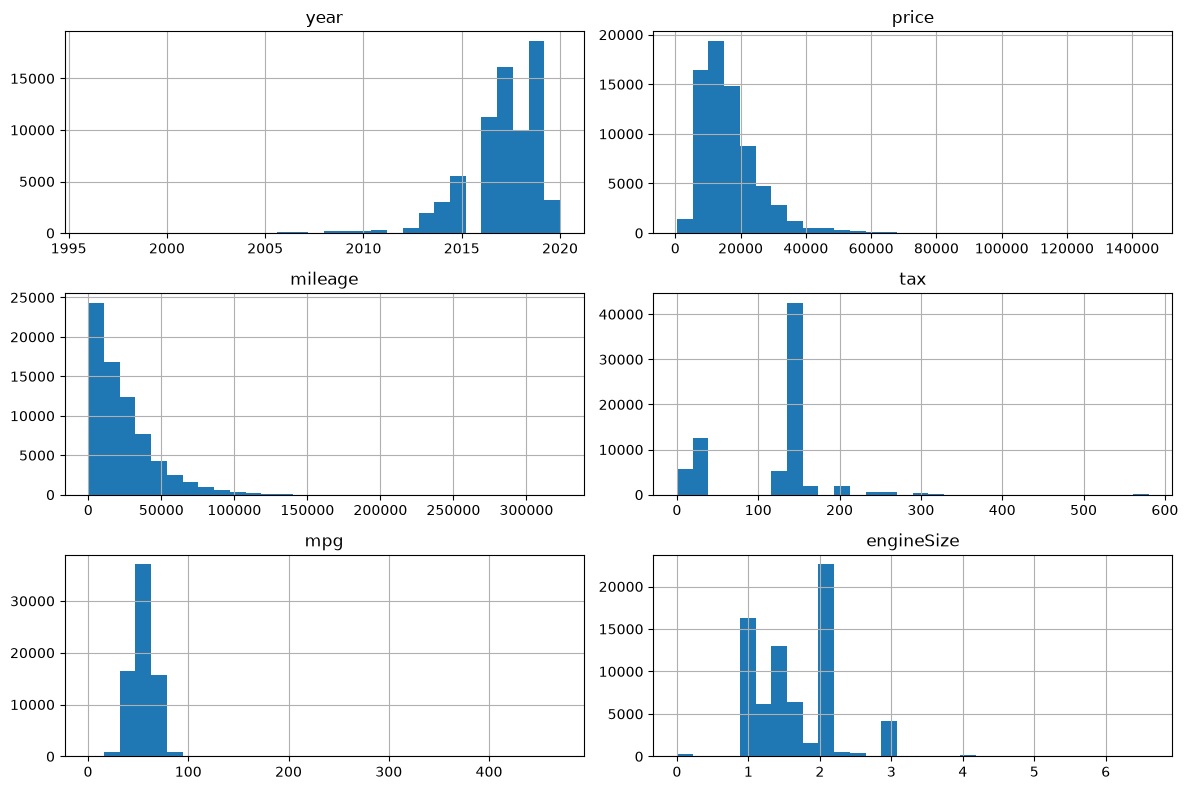

In [13]:
df.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

## Boxplot Analysis

A boxplot was used to visualize the distribution of the numerical features and identify potential outliers.


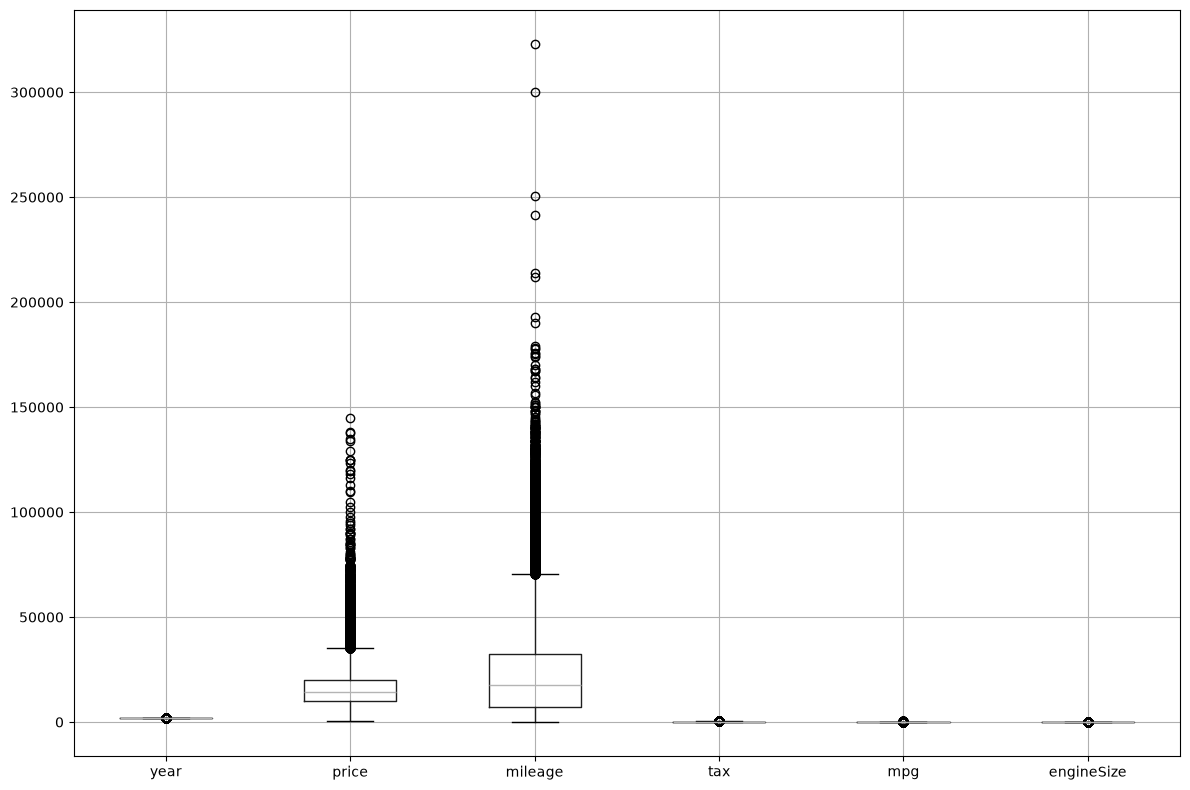

In [14]:
df.boxplot(figsize=(12,8))
plt.tight_layout()
plt.show()

## Categorical Feature Analysis

Countplots were used to visualize the frequency of different categories in the categorical features.

The following features were analyzed:

- `transmission`
- `fuelType`
- `Make`

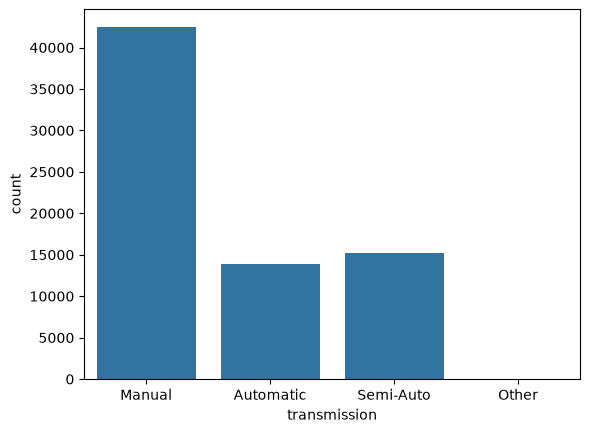

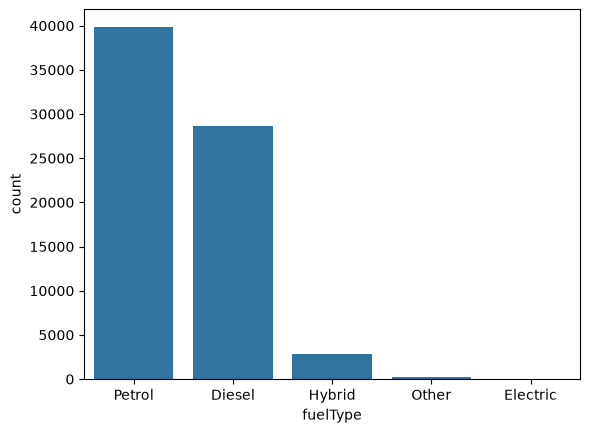

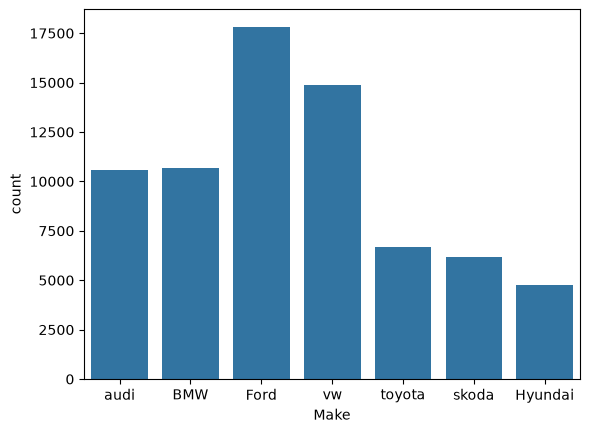

In [15]:
categorical= [ "transmission", "fuelType", "Make"]
for col in categorical:
    sns.countplot(x=df[col])
    plt.show()

##  Pairplot Analysis

A pairplot was used to visualize the **pairwise relationships between numerical features** in the dataset.


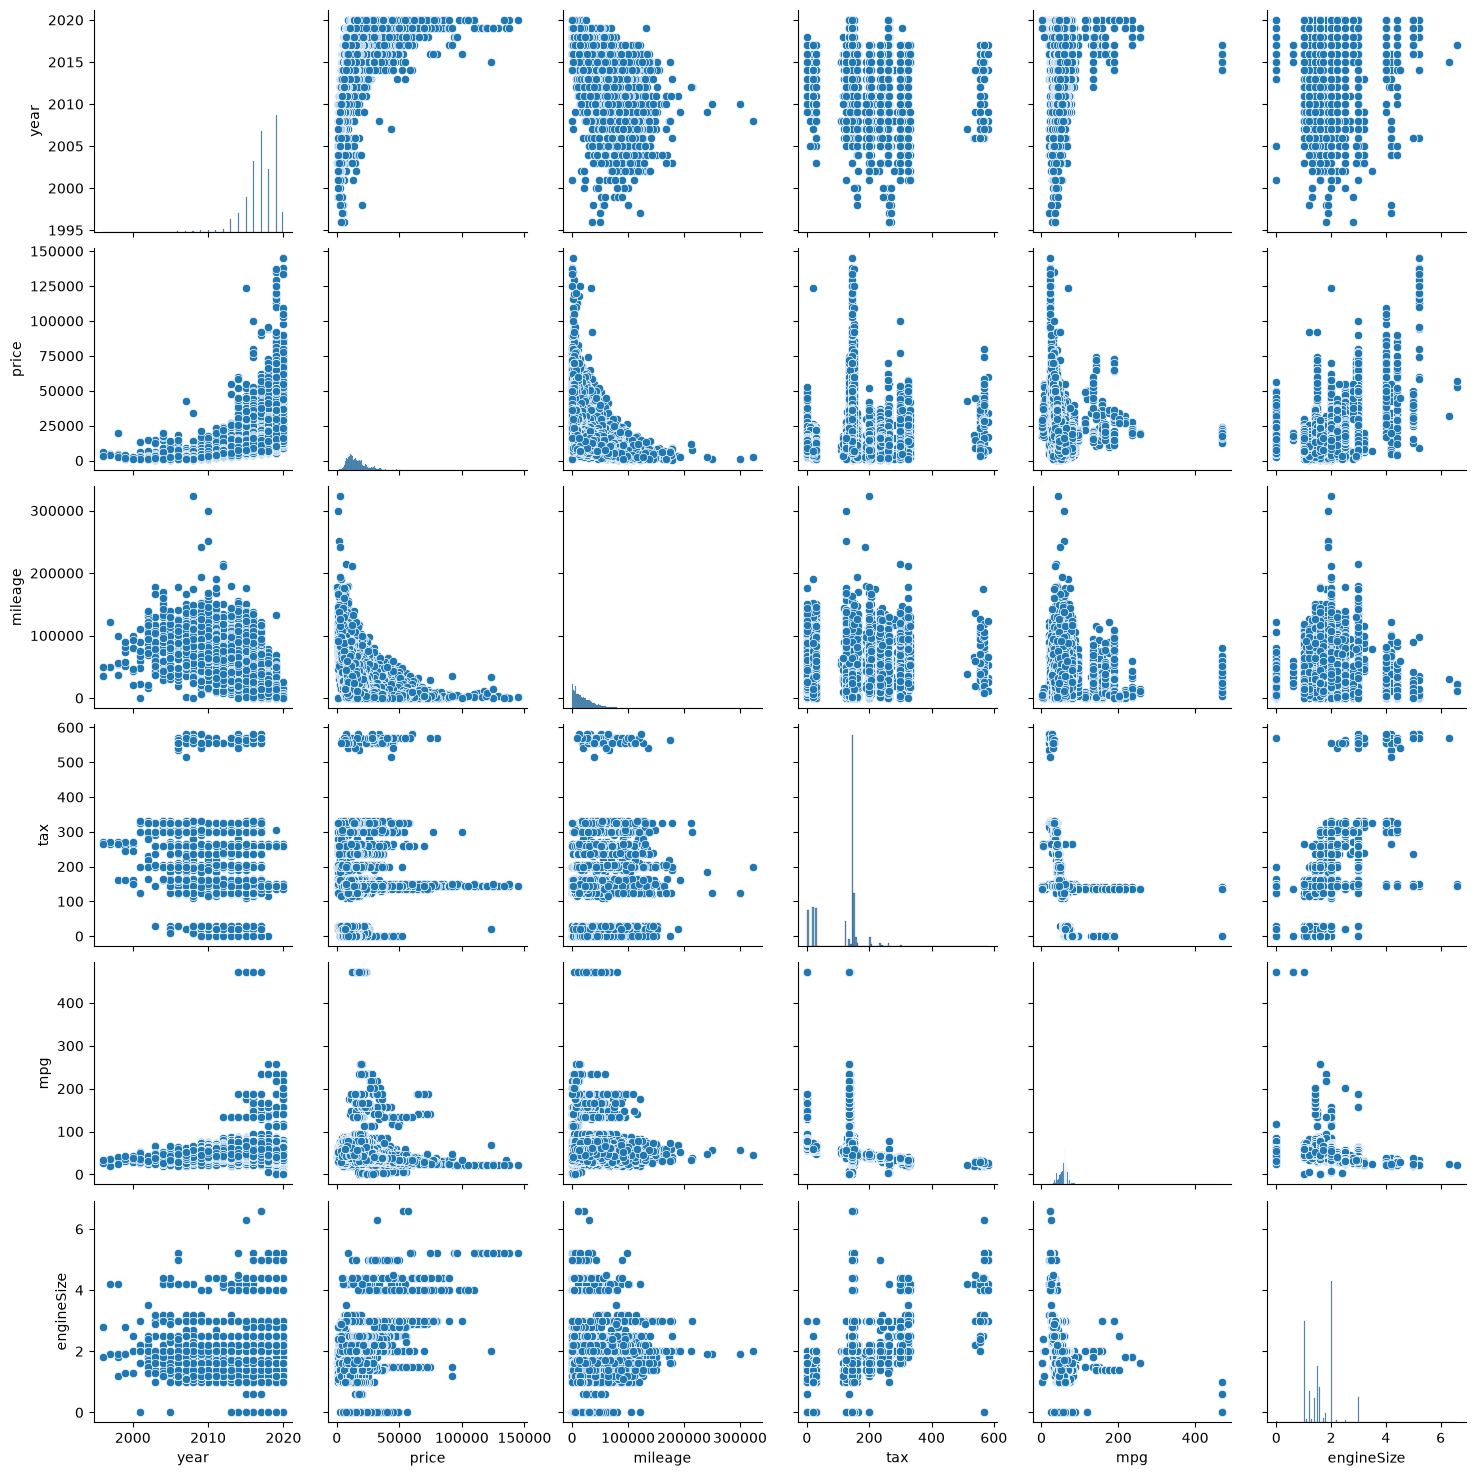

In [16]:
sns.pairplot(df)
plt.show()

##  Correlation Heatmap

A correlation heatmap was created to examine the **relationships between numerical features** in the dataset.



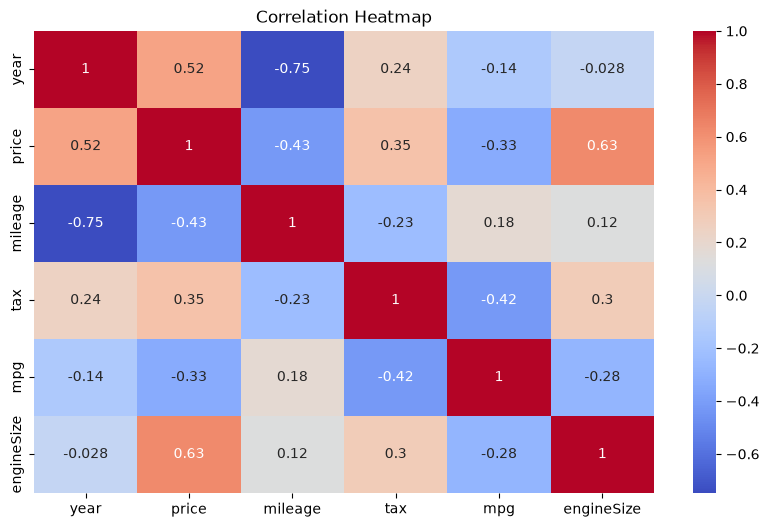

In [17]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

##  Price Distribution by Fuel Type

A boxplot was used to compare the **distribution of car prices across different fuel types**.


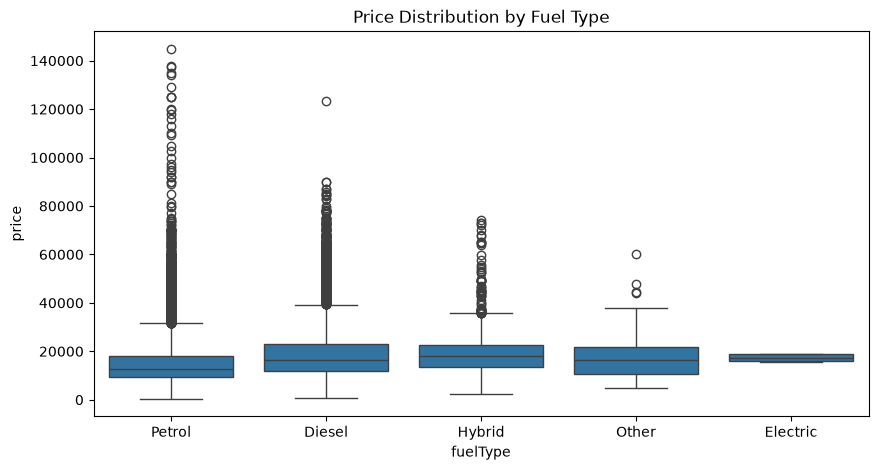

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="fuelType", y="price")

plt.title("Price Distribution by Fuel Type")
plt.show()

## Price Distribution by Transmission

A boxplot was used to compare the **distribution of car prices across different transmission types**.

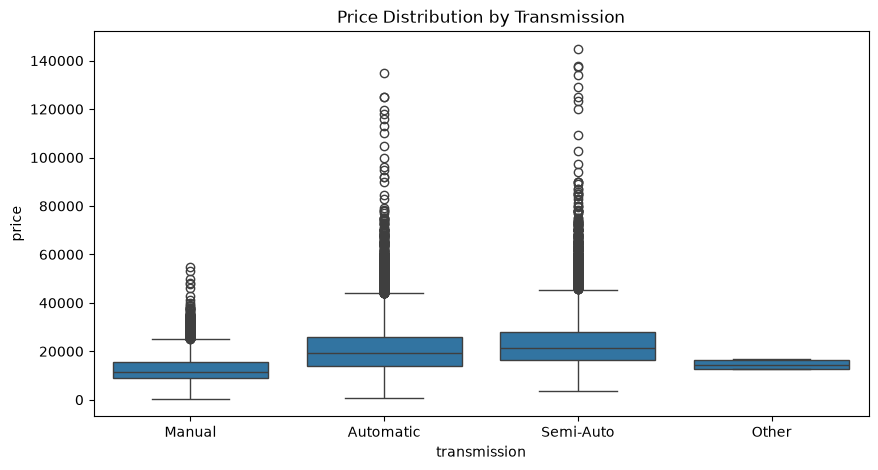

In [19]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="transmission", y="price")

plt.title("Price Distribution by Transmission")
plt.show()

## Price Distribution by Make

A boxplot was used to compare the **distribution of car prices across different car manufacturers (Make)**.


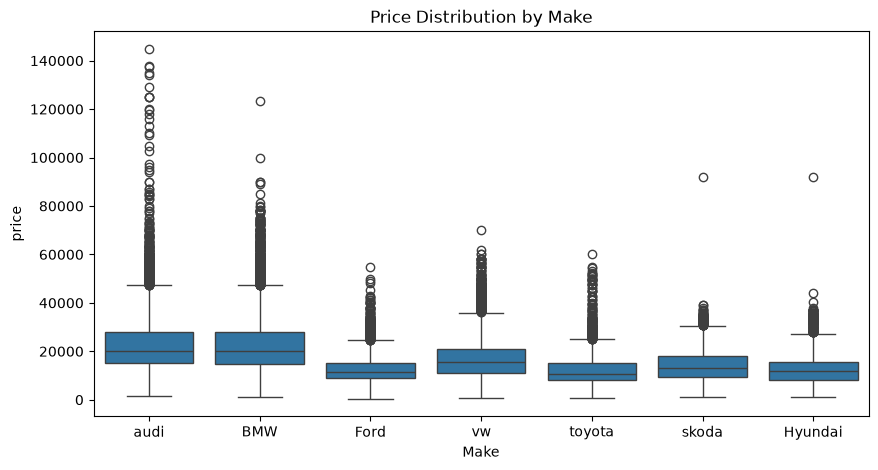

In [20]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="Make", y="price")

plt.title("Price Distribution by Make")
plt.show()

#  Baseline Model — Numerical Features

A baseline Linear Regression model is developed using only the numerical features of the dataset.

The selected features are `year`, `mileage`, `tax`, `mpg`, and `engineSize`, while `price` is used as the target variable.

The dataset is divided into training and testing sets, and a Linear Regression model is trained using the training data. The model's coefficients and predictions are then examined before evaluating its performance using regression metrics.

## Defining Features and Target

The dataset was divided into **independent features (`X`)** and the **target variable (`y`)** for the Linear Regression model.


In [21]:
X = df[["year", "mileage", "tax", "mpg", "engineSize"]]
y= df["price"]

##  Splitting the Dataset

The dataset was split into **training and testing sets** using `train_test_split()`.


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##  Training the Linear Regression Model

A **Linear Regression** model was created and trained using the training data.


In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 1583.43, -0.1 , -0.08, -27.08,10770.18]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['year','mileage','tax','mpg','engineSize']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.191e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


## Model Intercept and Coefficients

The intercept and coefficients learned by the Linear Regression model were displayed.

In [24]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -3191104.2716495865
Coefficients: [ 1.58343452e+03 -1.00031914e-01 -7.99976906e-02 -2.70806871e+01
  1.07701784e+04]


## Feature Coefficients

The coefficient for each feature was displayed along with its corresponding feature name.

In [25]:
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)

year : 1583.4345196922857
mileage : -0.10003191402108316
tax : -0.07999769059178419
mpg : -27.08068708377831
engineSize : 10770.178447093924


## Making Predictions

The trained Linear Regression model was used to predict car prices for the testing dataset.


In [26]:
y_pred = model.predict(X_test)

## Model Evaluation

The trained Linear Regression model was evaluated using **Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score**.


In [27]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 24255227.067660373
RMSE: 4924.959600612006
R²: 0.7238484410365834


#  Regression Metrics and Variance Analysis

The baseline model is evaluated using standard regression metrics to measure prediction performance.

MSE and RMSE measure the prediction error, while R² measures the proportion of variation in car prices explained by the model.

In addition, SST, SSE, and SSR are calculated to understand the total, unexplained, and explained variation in the target variable. The manually calculated R² values are compared using two equivalent formulas to verify the relationship between these regression components.

##  Mean Price of Test Data

The mean price of the test dataset was calculated to use as a reference for evaluating the model's predictions.


In [28]:
y_mean = y_test.mean()

print("Mean Price:", y_mean)

Mean Price: 16547.39688525735


##  Total Sum of Squares (SST)

The **Total Sum of Squares (SST)** was calculated to measure the total variation of the actual car prices around their mean.


In [29]:
SST = np.sum((y_test - y_mean) ** 2)

print("SST:", SST)

SST: 1257681099775.501


##  Sum of Squared Errors (SSE)

The **Sum of Squared Errors (SSE)** was calculated to measure the total squared difference between the actual and predicted car prices.


In [30]:
SSE = np.sum((y_test - y_pred) ** 2)

print("SSE:", SSE)

SSE: 347310596381.82886


##  Regression Sum of Squares (SSR)

The **Regression Sum of Squares (SSR)** measures the amount of variation in the actual car prices that is explained by the regression model.


In [31]:
SSR = np.sum((y_pred - y_mean) ** 2)

print("SSR:", SSR)

SSR: 876678511816.4344


## Verifying the Regression Components

The values of **SST, SSR, and SSE** were compared to verify the relationship between the total, explained, and unexplained variation.


In [32]:
print("SST:", SST)
print("SSR:", SSR)
print("SSE:", SSE)
print("SSR + SSE:", SSR + SSE)

SST: 1257681099775.501
SSR: 876678511816.4344
SSE: 347310596381.82886
SSR + SSE: 1223989108198.2632


## Manual R² Calculation

The R² score was calculated manually using the **Regression Sum of Squares (SSR)** and **Total Sum of Squares (SST)**.



In [33]:
r2_manual = SSR / SST

print("R² (manual):", r2_manual)

R² (manual): 0.6970594628264062


##  Verifying R² Using Two Formulas

R² was calculated using two equivalent formulas to verify the result.

In [34]:
r2_1 = SSR / SST
r2_2 = 1 - (SSE / SST)

print("R² using SSR/SST:", r2_1)
print("R² using 1-SSE/SST:", r2_2)

R² using SSR/SST: 0.6970594628264062
R² using 1-SSE/SST: 0.7238484410365834


#  Actual vs Predicted Prices

The model's predictions are visualized by comparing the actual car prices with the predicted prices.

A scatter plot is used to examine how closely the predictions follow the actual values. An ideal reference line is also included, where the actual and predicted prices are equal.

Points closer to the reference line indicate more accurate predictions, while points farther away represent larger prediction errors.

##  Actual vs Predicted Car Prices

A scatter plot was created to compare the **actual car prices** with the **prices predicted by the Linear Regression model**.


In [2]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

NameError: name 'y_test' is not defined

<Figure size 800x600 with 0 Axes>

##  Actual vs Predicted Car Prices

A scatter plot with a reference line was created to compare the **actual car prices** with the prices predicted by the Linear Regression model.


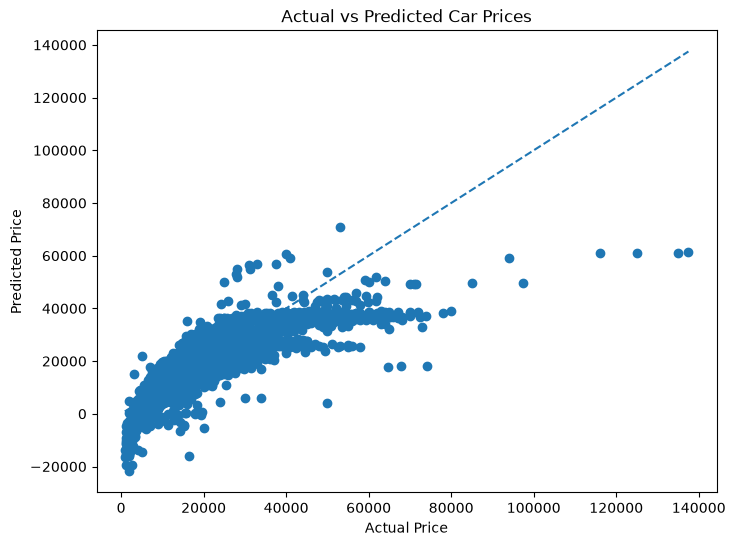

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

#  Overfitting Analysis

The baseline model is evaluated on both the training and testing datasets to check how well it generalizes to unseen data.

Training and testing R² scores are compared to identify whether there is a large performance difference between the data used for training and unseen data.

A large difference may indicate overfitting, while similar training and testing performance suggests that the model is generalizing reasonably well.

##  Training vs Testing R²

The R² score was calculated separately for the **training** and **testing** datasets to check how well the model performs on data it has seen compared with unseen data.



In [37]:
y_train_pred = model.predict(X_train)
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.7099276630019752
Testing R²: 0.7238484410365834


#  Model Improvement Using EDA

The baseline model uses only numerical features. Based on the observations from the exploratory data analysis, additional categorical features are included to provide the model with more information about each car.

The final feature set includes numerical features such as `year`, `mileage`, `tax`, `mpg`, and `engineSize`, along with categorical features such as `transmission`, `fuelType`, `Make`, and `model`.

This allows the improved model to capture differences in car prices associated with different manufacturers, models, fuel types, and transmission types.

##  Defining Features for the Final Model

For the final model, both **numerical and categorical features** were selected based on the EDA and earlier model comparisons.



In [38]:
numerical_features = [
    "year",
    "mileage",
    "tax",
    "mpg",
    "engineSize"
]

categorical_features = [
    "transmission",
    "fuelType",
    "Make",
    "model"
]

X = df[numerical_features + categorical_features]
y = df["price"]

#  Final Model — Preprocessing and Pipeline

The improved model uses both numerical and categorical features. Since Linear Regression requires numerical inputs, the categorical features must first be converted into numerical representations.

The dataset is divided into training, validation, and testing sets. A `ColumnTransformer` is used to apply appropriate preprocessing to numerical and categorical features, with One-Hot Encoding applied to the categorical variables.

The preprocessing step and Linear Regression model are then combined into a single Scikit-learn `Pipeline`. This ensures that the same preprocessing process is consistently applied during training, validation, testing, and future predictions.

##  Train / Validation / Test Split

The dataset was divided into three subsets: **training, validation, and testing data**.



In [39]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test.shape)

Training data: (45819, 9)
Validation data: (11455, 9)
Testing data: (14319, 9)


##  Preprocessing Categorical Features

A `ColumnTransformer` was used to apply different preprocessing steps to numerical and categorical features.


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

##  Creating the Machine Learning Pipeline

A **Pipeline** was created to combine the preprocessing step with the Linear Regression model into a single workflow.


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

##  Training the Pipeline

The complete machine learning pipeline was trained using the training dataset.


In [42]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['year','mileage','tax',...,'fuelType','Make','model']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated wi

#  Final Model Evaluation

After training the complete preprocessing and Linear Regression pipeline, the improved model is evaluated using the validation and test datasets.

The validation set is used to evaluate the model during development, while the test set is kept separate for the final evaluation on unseen data.

MSE, RMSE, and R² are calculated for both validation and testing data. Training and testing performance are also compared to check the model's generalization and identify any obvious signs of overfitting.

##  Validation Set Evaluation

The trained pipeline was evaluated on the **validation dataset** using MSE, RMSE, and R².
- **Validation MSE** measures the average squared prediction error.
- **Validation RMSE** represents the prediction error in the same unit as car price.
- **Validation R²** measures how much variation in car prices is explained by the model on the validation data.

In [43]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_val_pred = pipeline.predict(X_val)

val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

print("Validation MSE:", val_mse)
print("Validation RMSE:", val_rmse)
print("Validation R²:", val_r2)

Validation MSE: 17408870.132252816
Validation RMSE: 4172.393813178811
Validation R²: 0.8053926490686335


##  Final Test Set Evaluation

After training and validation, the pipeline was evaluated on the **test dataset** to measure its final performance on unseen data.


In [44]:
y_test_pred = pipeline.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

Test MSE: 15485594.565420354
Test RMSE: 3935.174019712515
Test R²: 0.823692803667134


##  Training vs Testing Performance

The model's performance on the **training** and **testing** datasets was compared using R² and RMSE.


In [47]:
y_train_pred_3 = pipeline.predict(X_train)

train_r2_3 = r2_score(y_train, y_train_pred_3)
test_r2_3 = r2_score(y_test, y_test_pred)

train_rmse_3 = np.sqrt(
    mean_squared_error(y_train, y_train_pred_3)
)

test_rmse_3 = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

print("Training R²:", train_r2_3)
print("Testing R²:", test_r2_3)

print("Training RMSE:", train_rmse_3)
print("Testing RMSE:", test_rmse_3)

Training R²: 0.8262140481425309
Testing R²: 0.823692803667134
Training RMSE: 3847.7987789079702
Testing RMSE: 3935.174019712515


#  Saving and Reusing the Trained Model

After completing model training and evaluation, the complete machine learning pipeline is saved using Python's Pickle module.

The saved file contains both the preprocessing steps and the trained Linear Regression model. This allows the model to be reused later without repeating the complete training process.

The saved model is then loaded again and used to make predictions, demonstrating how a trained machine learning model can be deployed and reused.

##  Saving the Trained Model

The trained machine learning pipeline was saved using Python's **Pickle** module so that it can be reused later without retraining the model.


In [48]:
import pickle

with open("car_price_model.pkl", "wb") as file:
    pickle.dump(pipeline, file)

print("Model saved successfully!")

Model saved successfully!


##  Loading the Saved Model

The saved machine learning pipeline was loaded from the Pickle file so that it can be reused without retraining the model.


In [49]:
with open("car_price_model.pkl", "rb") as file:
    model = pickle.load(file)

##  Making Predictions Using the Saved Model

The loaded model was used to generate predictions for the test dataset.



In [50]:
model.predict(X_test)

array([12732.49461796, 19568.97762236, 27585.9618595 , ...,
        9066.55363525, 17045.96387365, 15405.38939632], shape=(14319,))

#  Conclusion

This project demonstrates a complete **machine learning workflow for predicting used car prices using Linear Regression**.

The process started with **data inspection and cleaning**, followed by **Exploratory Data Analysis (EDA)** to understand the distributions, relationships, and patterns in the dataset. The EDA insights were then used to select relevant numerical and categorical features for model improvement.

A baseline Linear Regression model was first trained using numerical features. The model was then improved by incorporating categorical features such as **car model, transmission, fuel type, and manufacturer**, using **One-Hot Encoding**.

The improved model was implemented using a **Scikit-learn Pipeline**, with separate training, validation, and testing datasets. Its performance was evaluated using **MSE, RMSE, and R²**, while training and testing results were compared to check for overfitting.

Finally, the complete trained pipeline was saved using **Pickle**, loaded again, and used to make predictions. This demonstrates how the trained model can be **stored, reused, and applied to new data without retraining**.

Overall, the project provides practical experience with **data preprocessing, EDA, feature selection, Linear Regression, model evaluation, pipelines, validation, and model serialization**.